In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

#import copula functions
from pr_copula.main_copula_regression_conditional import fit_copula_cregression,predict_copula_cregression,predictive_resample_cregression,check_convergence_pr_cregression

from copula_mp import mp_density, mp_density_t_learner, mp_density_att, mp_density_att_logistic
from copula_mp_iv import mp_density_iv, mp_compliers

## The effect of Zinc supplementation on the duration of the common cold

In [25]:
# load data
d = pd.read_csv("Data/ZnAcet.csv")

y = d.Duration.values
x = d.Zinc.values
w = np.ones(len(y))

# compute standardisation parameters and standardise y
mu_y = y.mean()
sig_y = y.std()
y_std = (y - mu_y) / sig_y

# run analysis â€” grid on standardised scale
T = 5000
B = 500

y_grid_orig = np.linspace(0, 18, 50)
y_grid_std = (y_grid_orig - mu_y) / sig_y

# single learner approach
res = mp_density(y_std, x, w, [0, 1], y_grid_std, B, T)

# twin learner approach
res_t = mp_density_t_learner(y_std, x, w, [0, 1], y_grid_std, B, T)



Compiling...
Compilation time: 2.464s
Optimizing...
Optimization time: 1.131s
Fitting...
Fit time: 0.027s
Optimised rho:  0.60132074
Optimised rho_x:  [0.8401232  0.00619007]
Prequential log-likelihhod:  -1.2659235000610352
Predicting...
Prediction time: 0.457s
Predictive resampling...
Predictive resampling time: 8.777s
Compiling...
Compilation time: 1.683s
Optimizing...
Optimization time: 0.27s
Fitting...
Fit time: 0.004s
Optimised rho for x=0:  0.6701834
Optimised rho_x for x=0:  [0.04114372 0.00157737]
Prequential log-likelihood for x=0:  -1.4737317562103271
Predicting...
Prediction time: 0.418s
Predictive resampling...
Predictive resampling time: 6.179s
Compiling...
Compilation time: 1.82s
Optimizing...
Optimization time: 0.361s
Fitting...
Fit time: 0.005s
Optimised rho for x=1:  0.71388704
Optimised rho_x for x=1:  [0.00402309 0.00402309]
Prequential log-likelihood for x=1:  -1.068336009979248
Predicting...
Prediction time: 0.386s
Predictive resampling...
Predictive resampling tim

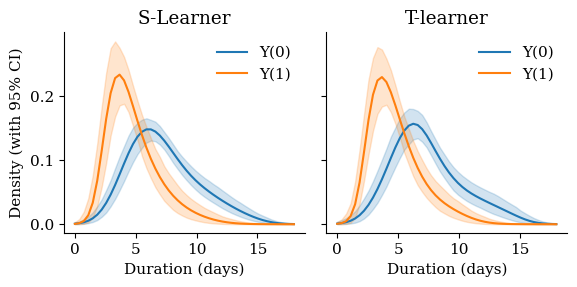

In [27]:

fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharey=True)

plt.rcParams.update({
    "font.family":      "serif",
    "font.size":        11,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.linewidth":   0.8,
    "xtick.direction":  "out",
    "ytick.direction":  "out",
})

# --- Panel 1: S-Learner ---
ax = axes[0]
ax.plot(y_grid_orig, res['x_0']['mean'] / sig_y, label="Y(0)", color='tab:blue')
ax.fill_between(y_grid_orig, res['x_0']['low'] / sig_y, res['x_0']['high'] / sig_y, color='tab:blue', alpha=0.2)
ax.plot(y_grid_orig, res['x_1']['mean'] / sig_y, label="Y(1)", color='tab:orange')
ax.fill_between(y_grid_orig, res['x_1']['low'] / sig_y, res['x_1']['high'] / sig_y, color='tab:orange', alpha=0.2)
ax.set_xlabel("Duration (days)")
ax.set_ylabel("Density (with 95% CI)")
ax.set_title("S-Learner")
ax.legend(frameon=False)

# --- Panel 2: T-learner ---
ax = axes[1]
ax.plot(y_grid_orig, res_t['x_0']['mean'] / sig_y, label="Y(0)", color='tab:blue')
ax.fill_between(y_grid_orig, res_t['x_0']['low'] / sig_y, res_t['x_0']['high'] / sig_y, color='tab:blue', alpha=0.2)
ax.plot(y_grid_orig, res_t['x_1']['mean'] / sig_y, label="Y(1)", color='tab:orange')
ax.fill_between(y_grid_orig, res_t['x_1']['low'] / sig_y, res_t['x_1']['high'] / sig_y, color='tab:orange', alpha=0.2)
ax.set_xlabel("Duration (days)")
ax.set_title("T-learner")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('Figures/ZincExample.pdf', dpi=300, bbox_inches='tight')
plt.show()


## A Vitamin A supplementation trial

In [2]:
# Sommer & Zeger Vitamin A Study Dataset
# Create the dataset from contingency table
data_counts = [
    (0, 0, 0, 74),      # Assigned: No, Received: No, Outcome: Died
    (0, 0, 1, 11514),   # Assigned: No, Received: No, Outcome: Survived
    (1, 0, 0, 34),      # Assigned: Yes, Received: No, Outcome: Died
    (1, 0, 1, 2385),    # Assigned: Yes, Received: No, Outcome: Survived
    (1, 1, 0, 12),      # Assigned: Yes, Received: Yes, Outcome: Died
    (1, 1, 1, 9663)     # Assigned: Yes, Received: Yes, Outcome: Survived
]

Z_data = []
X_data = []
Y_data = []

for z, x, y, count in data_counts:
    Z_data.extend([z] * count)
    X_data.extend([x] * count)
    Y_data.extend([y] * count)

Z_data = np.array(Z_data)
X_data = np.array(X_data)
Y_data = np.array(Y_data)

print(f"Total observations: {len(Y_data)}")
print(f"Outcome distribution: {np.mean(Y_data):.4f}")
print(f"Treatment (X=1) rate: {np.mean(X_data):.4f}")
print(f"Instrument (Z=1) rate: {np.mean(Z_data):.4f}")

# Summary statistics by instrument assignment
print("\nSummary by Instrument Assignment:")
print(f"  Z=0: P(X=1|Z=0) = {np.mean(X_data[Z_data == 0]):.4f}")
print(f"  Z=1: P(X=1|Z=1) = {np.mean(X_data[Z_data == 1]):.4f}")

Total observations: 23682
Outcome distribution: 0.9949
Treatment (X=1) rate: 0.4085
Instrument (Z=1) rate: 0.5107

Summary by Instrument Assignment:
  Z=0: P(X=1|Z=0) = 0.0000
  Z=1: P(X=1|Z=1) = 0.8000


In [3]:
# Run mp_compliers with Bayesian bootstrap approach
# For binary outcomes with complier identification
B_post = 1000  # Number of posterior samples
T_fwd = 100000 - len(Y_data)

np.random.seed(42)
results_compliers = mp_compliers(Y_data, X_data, Z_data, B_post, T_fwd)

In [23]:
# report the comlier proportion
print("90% CI for the complier proportion: ", np.quantile(results_compliers['Complier'], [0.05, 0.95]))

# report the LATE estimates
print(
    "90% CI for the LATE (per 1000 individuals): ",
    1000 * np.quantile(results_compliers['Treatment'] - results_compliers['Control'], [0.05, 0.95])
)

90% CI for the complier proportion:  [0.79487741 0.80521985]
90% CI for the LATE (per 1000 individuals):  [1.56763243 4.84062739]


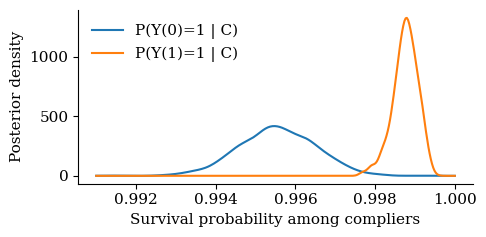

In [25]:
from scipy.stats import gaussian_kde

p_y0_samples = results_compliers['Control']
p_y1_samples = results_compliers['Treatment']

plt.rcParams.update({
    "font.family":      "serif",
    "font.size":        11,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.linewidth":   0.8,
    "xtick.direction":  "out",
    "ytick.direction":  "out",
})

fig, ax = plt.subplots(figsize=(5, 2.5))

for samples, label in [(p_y0_samples, 'P(Y(0)=1 | C)'), (p_y1_samples, 'P(Y(1)=1 | C)')]:
    kde = gaussian_kde(samples)
    x = np.linspace(0.991, 1, 300)
    ax.plot(x, kde(x), label=label)

ax.set_xlabel('Survival probability among compliers')
ax.set_ylabel('Posterior density')
ax.legend(frameon = False)
plt.tight_layout()
plt.savefig("Figures/Sommer_Zeger_Results.pdf")
plt.show()

## Lalonde

In [2]:
# load data
d = pd.read_csv("Data/lalonde.csv")

y = d.re78.values
x = d.treat.values
w = d[['age', 'educ', 'hisp', 'black', 'married', 'nodegr', 're74', 're75', 'u74', 'u75']].values

print("Number of treated and control observations:", x.sum(), d.shape[0] - x.sum())

Number of treated and control observations: 185 260


In [3]:

# compute standardisation parameters and standardise y
mu_y = y.mean()
sig_y = y.std()
y_std = (y - mu_y) / sig_y

w_std = (w - w.mean(axis=0)) / w.std(axis=0)

# run analysis on standardised grid
T = 1500 - len(y)
B = 200

y_grid_orig = np.linspace(0, 25000, 50)
y_grid_std = (y_grid_orig - mu_y) / sig_y

# Counterfactual outcomes among treated Y(0)|X = 1 and Y(1)|X = 1
res_tt = mp_density_att(y_std, x, w_std, y_grid_std, B, T)

# logistic regression as comparison
res_log = mp_density_att_logistic(y_std, x, w_std, y_grid_std, B, T)


Compiling...
Compilation time: 2.915s
Optimizing...
Optimization time: 14.816s
Fitting...
Fit time: 0.073s
Optimised rho:  0.089153044
Optimised rho_x:  [0.99753475 0.836414   0.11034292 0.4889191  0.90573835 0.02386261
 0.7808865  0.9762597  0.52488136 0.9141188  0.88405436]
Prequential log-likelihhod:  -1.3424714803695679
Predicting...
Prediction time: 3.585s
Predictive resampling...
Predictive resampling time: 84.778s
Compiling...
Compilation time: 0.44s
Optimizing...
Optimization time: 11.291s
Fitting...
Fit time: 0.074s
Optimised rho:  0.089153044
Optimised rho_x:  [0.99753475 0.836414   0.11034292 0.4889191  0.90573835 0.02386261
 0.7808865  0.9762597  0.52488136 0.9141188  0.88405436]
Prequential log-likelihhod:  -1.3424714803695679
Predicting...
Prediction time: 4.448s
Predictive resampling...
Predictive resampling time: 51.386s


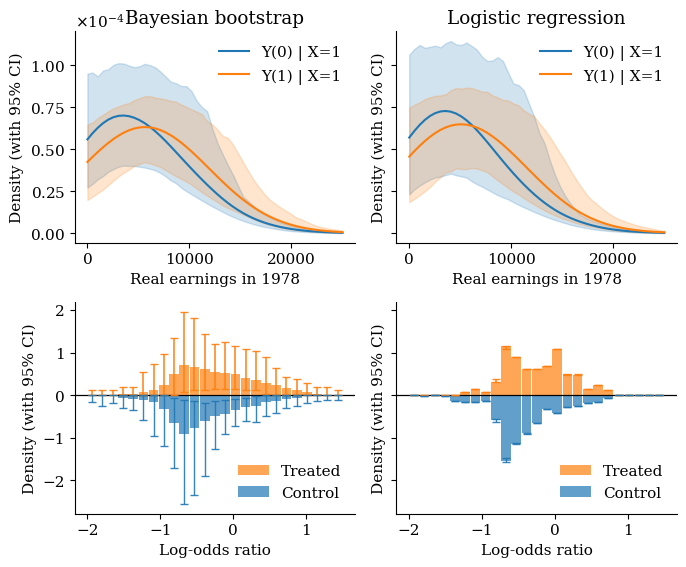

In [4]:
plt.rcParams.update({
    "font.family":      "serif",
    "font.size":        11,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.linewidth":   0.8,
    "xtick.direction":  "out",
    "ytick.direction":  "out",
})

fig, axes = plt.subplots(2, 2, figsize=(7, 6), sharey='row')

bins = np.linspace(-2, 1.5, 26)
bin_centres = 0.5 * (bins[:-1] + bins[1:])
width = bins[1] - bins[0]

def _hist_density(lo_samples, x_flag, B_post):
    out = np.zeros((B_post, len(bins) - 1))
    for b in range(B_post):
        vals = lo_samples[b, x == x_flag]
        counts, _ = np.histogram(vals, bins=bins, density=True)
        out[b] = counts
    return out

def _plot_att_densities(ax, res, title):
    ax.plot(y_grid_orig, res['x_0']['mean'] / sig_y, label="Y(0) | X=1", color='tab:blue')
    ax.fill_between(y_grid_orig, res['x_0']['low'] / sig_y, res['x_0']['high'] / sig_y, color='tab:blue', alpha=0.2)
    ax.plot(y_grid_orig, res['x_1']['mean'] / sig_y, label="Y(1) | X=1", color='tab:orange')
    ax.fill_between(y_grid_orig, res['x_1']['low'] / sig_y, res['x_1']['high'] / sig_y, color='tab:orange', alpha=0.2)
    ax.set_xlabel("Real earnings in 1978")
    ax.set_xticks([0, 10000, 20000])
    ax.set_ylabel("Density (with 95% CI)")
    ax.set_title(title)
    ax.legend(frameon=False)
    fmt = ticker.ScalarFormatter(useMathText=True)
    fmt.set_powerlimits((0, 0))
    ax.yaxis.set_major_formatter(fmt)

def _plot_propensity_hist(ax, res):
    ps = res['propensity_scores']  # (B_post, n)
    log_odds = np.log(np.clip(ps, 1e-6, 1 - 1e-6) / np.clip(1 - ps, 1e-6, 1 - 1e-6))
    B_post = ps.shape[0]

    hist_trt  = _hist_density(log_odds, 1, B_post)
    hist_ctrl = _hist_density(log_odds, 0, B_post)

    # use the median rather than the mean: since lo/hi are the 2.5%/97.5% quantiles
    # of the same samples, the median is guaranteed to lie between them (quantiles
    # are monotonic), so the error-bar lengths med - lo and hi - med are always >= 0
    med_trt = np.quantile(hist_trt,  0.5,   axis=0)
    lo_trt  = np.quantile(hist_trt,  0.025, axis=0)
    hi_trt  = np.quantile(hist_trt,  0.975, axis=0)

    med_ctrl = np.quantile(hist_ctrl, 0.5,   axis=0)
    lo_ctrl  = np.quantile(hist_ctrl, 0.025, axis=0)
    hi_ctrl  = np.quantile(hist_ctrl, 0.975, axis=0)

    ax.axhline(0, color='black', linewidth=0.9)

    ax.bar(bin_centres,  med_trt,  width=width * 0.95, color='tab:orange', label='Treated', alpha=0.7)
    ax.errorbar(bin_centres, med_trt, yerr=[med_trt - lo_trt, hi_trt - med_trt],
                fmt='none', color='tab:orange', capsize=3, linewidth=1.2, alpha=0.9)

    ax.bar(bin_centres, -med_ctrl, width=width * 0.95, color='tab:blue', label='Control', alpha=0.7)
    ax.errorbar(bin_centres, -med_ctrl, yerr=[hi_ctrl - med_ctrl, med_ctrl - lo_ctrl],
                fmt='none', color='tab:blue', capsize=3, linewidth=1.0, alpha=0.9)

    ax.set_xlabel("Log-odds ratio")
    ax.set_ylabel("Density (with 95% CI)")
    ax.legend(frameon=False)

# Left column: Bayesian bootstrap approach (mp_density_att)
_plot_att_densities(axes[0, 0], res_tt, "Bayesian bootstrap")
_plot_propensity_hist(axes[1, 0], res_tt)

# Right column: logistic regression / natural gradient approach (mp_density_att_logistic)
_plot_att_densities(axes[0, 1], res_log, "Logistic regression")
_plot_propensity_hist(axes[1, 1], res_log)

plt.tight_layout()
plt.savefig('Figures/LalondeExample.pdf', dpi=300, bbox_inches='tight')
plt.show()